In [4]:
# ============================================================
# CELL 1: Imports, reproducibility, and output directories
# ============================================================

import os
import sys
import json
import random
import shutil
import platform
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms, models

from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# Kaggle paths
# ------------------------------------------------------------

KAGGLE_INPUT_DIR = Path("/kaggle/input")
KAGGLE_WORKING_DIR = Path("/kaggle/working")

PROJECT_DIR = (
    KAGGLE_WORKING_DIR /
    "ATDL_Baseline_ResNet18"
)

CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
PLOT_DIR = PROJECT_DIR / "plots"
LOG_DIR = PROJECT_DIR / "logs"
RESULT_DIR = PROJECT_DIR / "results"
CONFIG_DIR = PROJECT_DIR / "config"
ENV_DIR = PROJECT_DIR / "environment"

for folder in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    PLOT_DIR,
    LOG_DIR,
    RESULT_DIR,
    CONFIG_DIR,
    ENV_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Environment information
# ------------------------------------------------------------

environment_info = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "device": str(DEVICE),
    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
    ),
    "seed": SEED,
}


with open(
    ENV_DIR / "environment.txt",
    "w"
) as f:

    for key, value in environment_info.items():
        f.write(f"{key}: {value}\n")


print("FP32 ResNet18 Baseline")

print(f"Device              : {DEVICE}")

if torch.cuda.is_available():

    print(
        f"GPU                 : "
        f"{torch.cuda.get_device_name(0)}"
    )

    print(
        f"GPU memory          : "
        f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )

print(f"PyTorch             : {torch.__version__}")
print(f"Torchvision         : {torchvision.__version__}")
print(f"Random seed         : {SEED}")

print("\nOutput directory:")
print(PROJECT_DIR)


FP32 ResNet18 Baseline
Device              : cuda
GPU                 : Tesla T4
GPU memory          : 15.64 GB
PyTorch             : 2.10.0+cu128
Torchvision         : 0.25.0+cu128
Random seed         : 42

Output directory:
/kaggle/working/ATDL_Baseline_ResNet18


In [5]:
# ============================================================
# CELL 2: ResNet18 baseline configuration
# ============================================================

CONFIG = {

    # Experiment
    "experiment_name":
        "ResNet18_FP32_CIFAR10_Baseline",

    "seed": SEED,

    # Dataset
    "num_classes": 10,

    "train_size": 45000,
    "validation_size": 5000,

    # Optimization
    "batch_size": 128,
    "max_epochs": 200,

    "optimizer": "SGD",

    "learning_rate": 0.1,

    "momentum": 0.9,

    "nesterov": True,

    "weight_decay": 5e-4,

    # Loss
    "label_smoothing": 0.1,

    # LR scheduling
    "warmup_epochs": 5,

    "scheduler":
        "5-epoch linear warmup + ReduceLROnPlateau",

    "plateau_factor": 0.5,

    "plateau_patience": 8,

    "minimum_learning_rate": 1e-4,

    # Early stopping
    "early_stopping_patience": 20,

    # Data augmentation
    "random_crop": {
        "size": 32,
        "padding": 4,
    },

    "horizontal_flip_probability": 0.5,

    "cutout_size": 8,

    # Normalization
    "normalization_mean":
        [0.4914, 0.4822, 0.4465],

    "normalization_std":
        [0.2470, 0.2435, 0.2616],

    # Model
    "architecture": "ResNet18",

    "precision": "FP32",

    "cifar_stem": True,

    # Important baseline restrictions
    "knowledge_distillation": False,

    "quantization": False,

    # Selection
    "checkpoint_selection":
        "highest validation accuracy"
}


BATCH_SIZE = CONFIG["batch_size"]
MAX_EPOCHS = CONFIG["max_epochs"]

BASE_LR = CONFIG["learning_rate"]

MOMENTUM = CONFIG["momentum"]

WEIGHT_DECAY = CONFIG["weight_decay"]

NESTEROV = CONFIG["nesterov"]

LABEL_SMOOTHING = (
    CONFIG["label_smoothing"]
)

WARMUP_EPOCHS = (
    CONFIG["warmup_epochs"]
)

PLATEAU_FACTOR = (
    CONFIG["plateau_factor"]
)

PLATEAU_PATIENCE = (
    CONFIG["plateau_patience"]
)

MIN_LR = (
    CONFIG["minimum_learning_rate"]
)

PATIENCE = (
    CONFIG["early_stopping_patience"]
)

VAL_SIZE = (
    CONFIG["validation_size"]
)

CUTOUT_SIZE = (
    CONFIG["cutout_size"]
)

CIFAR_MEAN = tuple(
    CONFIG["normalization_mean"]
)

CIFAR_STD = tuple(
    CONFIG["normalization_std"]
)

NUM_WORKERS = min(
    4,
    os.cpu_count() or 2
)

CONFIG["num_workers"] = NUM_WORKERS


with open(
    CONFIG_DIR / "baseline_config.json",
    "w"
) as f:

    json.dump(
        CONFIG,
        f,
        indent=4
    )


print(json.dumps(
    CONFIG,
    indent=4
))

{
    "experiment_name": "ResNet18_FP32_CIFAR10_Baseline",
    "seed": 42,
    "num_classes": 10,
    "train_size": 45000,
    "validation_size": 5000,
    "batch_size": 128,
    "max_epochs": 200,
    "optimizer": "SGD",
    "learning_rate": 0.1,
    "momentum": 0.9,
    "nesterov": true,
    "weight_decay": 0.0005,
    "label_smoothing": 0.1,
    "warmup_epochs": 5,
    "scheduler": "5-epoch linear warmup + ReduceLROnPlateau",
    "plateau_factor": 0.5,
    "plateau_patience": 8,
    "minimum_learning_rate": 0.0001,
    "early_stopping_patience": 20,
    "random_crop": {
        "size": 32,
        "padding": 4
    },
    "horizontal_flip_probability": 0.5,
    "cutout_size": 8,
    "normalization_mean": [
        0.4914,
        0.4822,
        0.4465
    ],
    "normalization_std": [
        0.247,
        0.2435,
        0.2616
    ],
    "architecture": "ResNet18",
    "precision": "FP32",
    "cifar_stem": true,
    "knowledge_distillation": false,
    "quantization": false,
   

In [7]:
# ============================================================
# CELL 3: Locate CIFAR-10 and teacher split indices
# ============================================================

print("Available Kaggle input sources:\n")

for path in sorted(
    KAGGLE_INPUT_DIR.iterdir()
):
    print(" -", path)


# ============================================================
# Locate CIFAR-10 batch directory
# ============================================================

required_cifar_files = {
    "data_batch_1",
    "data_batch_2",
    "data_batch_3",
    "data_batch_4",
    "data_batch_5",
    "test_batch",
    "batches.meta",
}


cifar_candidates = []


for batch_file in KAGGLE_INPUT_DIR.rglob(
    "data_batch_1"
):

    candidate_dir = batch_file.parent

    existing_files = {
        p.name
        for p in candidate_dir.iterdir()
        if p.is_file()
    }

    if required_cifar_files.issubset(
        existing_files
    ):
        cifar_candidates.append(
            candidate_dir
        )


if not cifar_candidates:

    raise FileNotFoundError(
        "Could not find CIFAR-10 Python "
        "batch files."
    )


CIFAR_BATCH_DIR = cifar_candidates[0]

CIFAR_ROOT = CIFAR_BATCH_DIR.parent


print("\nCIFAR-10 batch directory:")
print(CIFAR_BATCH_DIR)

print("\nTorchvision CIFAR root:")
print(CIFAR_ROOT)


# ============================================================
# Locate Notebook 1 train/validation split
# ============================================================

split_candidates = list(
    KAGGLE_INPUT_DIR.rglob(
        "cifar10_split_indices.npz"
    )
)


if not split_candidates:

    raise FileNotFoundError(
        "Could not find "
        "cifar10_split_indices.npz "
        "from Notebook 1."
    )


TEACHER_SPLIT_PATH = (
    split_candidates[0]
)


print("\nNotebook 1 split file:")
print(TEACHER_SPLIT_PATH)



Available Kaggle input sources:

 - /kaggle/input/datasets

CIFAR-10 batch directory:
/kaggle/input/datasets/kshitianilkumar/cifar-10/cifar/data/cifar-10-batches-py

Torchvision CIFAR root:
/kaggle/input/datasets/kshitianilkumar/cifar-10/cifar/data

Notebook 1 split file:
/kaggle/input/datasets/kshitianilkumar/atdl-teacher-resnet34/ATDL_Teacher_ResNet34/config/cifar10_split_indices.npz


In [8]:
# ============================================================
# CELL 4: Cutout and CIFAR-10 transformations
# ============================================================

class Cutout:

    def __init__(self, size=8):
        self.size = size

    def __call__(self, tensor):

        if not torch.is_tensor(tensor):

            raise TypeError(
                "Cutout expects a torch Tensor."
            )

        _, height, width = tensor.shape

        center_y = torch.randint(
            0,
            height,
            (1,)
        ).item()

        center_x = torch.randint(
            0,
            width,
            (1,)
        ).item()

        half = self.size // 2

        y1 = max(
            0,
            center_y - half
        )

        y2 = min(
            height,
            center_y + half
        )

        x1 = max(
            0,
            center_x - half
        )

        x2 = min(
            width,
            center_x + half
        )

        tensor = tensor.clone()

        tensor[
            :,
            y1:y2,
            x1:x2
        ] = 0.0

        return tensor


train_transform = transforms.Compose([

    transforms.RandomCrop(
        32,
        padding=4
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ToTensor(),

    Cutout(
        size=CUTOUT_SIZE
    ),

    transforms.Normalize(
        CIFAR_MEAN,
        CIFAR_STD
    ),
])


eval_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        CIFAR_MEAN,
        CIFAR_STD
    ),
])


print("Training transform:")
print(train_transform)

print("\nValidation/Test transform:")
print(eval_transform)

Training transform:
Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)

Validation/Test transform:
Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)


In [9]:
# ============================================================
# CELL 5: Load existing CIFAR-10 data
# ============================================================

base_train_dataset = datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=True,
    download=False,
    transform=None
)


print(
    "Original CIFAR-10 training samples:",
    len(base_train_dataset)
)

print("\nClasses:")
print(
    base_train_dataset.classes
)


assert (
    len(base_train_dataset) == 50000
)

assert (
    len(base_train_dataset.classes) == 10
)


print(
    "\nCIFAR-10 loaded using download=False."
)

Original CIFAR-10 training samples: 50000

Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

CIFAR-10 loaded using download=False.


In [11]:
# ============================================================
# CELL 6: Reuse exact teacher train/validation split
# ============================================================

split_data = np.load(
    TEACHER_SPLIT_PATH
)


train_indices = split_data[
    "train_indices"
]

val_indices = split_data[
    "val_indices"
]


print(
    "Training samples   :",
    len(train_indices)
)

print(
    "Validation samples :",
    len(val_indices)
)


assert len(train_indices) == 45000

assert len(val_indices) == 5000


overlap = np.intersect1d(
    train_indices,
    val_indices
)


assert len(overlap) == 0


# ------------------------------------------------------------
# Verify class distribution
# ------------------------------------------------------------

targets = np.array(
    base_train_dataset.targets
)

train_distribution = Counter(
    targets[train_indices]
)

val_distribution = Counter(
    targets[val_indices]
)


print("\nTraining distribution:")

for class_id in range(10):

    print(
        f"{base_train_dataset.classes[class_id]:10s}: "
        f"{train_distribution[class_id]}"
    )


print("\nValidation distribution:")

for class_id in range(10):

    print(
        f"{base_train_dataset.classes[class_id]:10s}: "
        f"{val_distribution[class_id]}"
    )


# Save a copy for Notebook 2 output
np.savez(
    CONFIG_DIR /
    "cifar10_split_indices.npz",

    train_indices=train_indices,

    val_indices=val_indices,

    seed=SEED
)



Training samples   : 45000
Validation samples : 5000

Training distribution:
airplane  : 4500
automobile: 4500
bird      : 4500
cat       : 4500
deer      : 4500
dog       : 4500
frog      : 4500
horse     : 4500
ship      : 4500
truck     : 4500

Validation distribution:
airplane  : 500
automobile: 500
bird      : 500
cat       : 500
deer      : 500
dog       : 500
frog      : 500
horse     : 500
ship      : 500
truck     : 500


In [12]:
# ============================================================
# CELL 7: Dataset wrapper
# ============================================================

class CIFARSubset(Dataset):

    def __init__(
        self,
        base_dataset,
        indices,
        transform=None
    ):

        self.base_dataset = (
            base_dataset
        )

        self.indices = np.asarray(
            indices
        )

        self.transform = transform


    def __len__(self):

        return len(
            self.indices
        )


    def __getitem__(self, idx):

        original_idx = (
            self.indices[idx]
        )

        image = (
            self.base_dataset.data[
                original_idx
            ]
        )

        label = (
            self.base_dataset.targets[
                original_idx
            ]
        )

        image = Image.fromarray(
            image
        )

        if self.transform is not None:

            image = self.transform(
                image
            )

        return image, label


train_dataset = CIFARSubset(
    base_train_dataset,
    train_indices,
    transform=train_transform
)


val_dataset = CIFARSubset(
    base_train_dataset,
    val_indices,
    transform=eval_transform
)


print(
    "Training dataset   :",
    len(train_dataset)
)

print(
    "Validation dataset :",
    len(val_dataset)
)


sample_image, sample_label = (
    train_dataset[0]
)


print(
    "\nSample tensor:",
    sample_image.shape
)

print(
    "Sample class:",
    base_train_dataset.classes[
        sample_label
    ]
)


assert (
    sample_image.shape ==
    (3, 32, 32)
)

Training dataset   : 45000
Validation dataset : 5000

Sample tensor: torch.Size([3, 32, 32])
Sample class: ship


In [13]:
# ============================================================
# CELL 8: DataLoaders
# ============================================================

def seed_worker(worker_id):

    worker_seed = (
        torch.initial_seed()
        % (2**32)
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


loader_generator = (
    torch.Generator()
)

loader_generator.manual_seed(
    SEED
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    persistent_workers=(
        NUM_WORKERS > 0
    ),

    worker_init_fn=seed_worker,

    generator=loader_generator
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    persistent_workers=(
        NUM_WORKERS > 0
    ),

    worker_init_fn=seed_worker
)


print(
    "Training batches   :",
    len(train_loader)
)

print(
    "Validation batches :",
    len(val_loader)
)


images, labels = next(
    iter(train_loader)
)


print(
    "\nBatch images:",
    images.shape
)

print(
    "Batch labels:",
    labels.shape
)

Training batches   : 352
Validation batches : 40

Batch images: torch.Size([128, 3, 32, 32])
Batch labels: torch.Size([128])


In [14]:
# ============================================================
# CELL 9: Build CIFAR-10 adapted ResNet18 baseline
# ============================================================

def build_cifar_resnet18(
    num_classes=10
):

    model = models.resnet18(
        weights=None,
        num_classes=num_classes
    )


    # CIFAR-10 stem
    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )


    nn.init.kaiming_normal_(
        model.conv1.weight,
        mode="fan_out",
        nonlinearity="relu"
    )


    # Remove ImageNet max pooling
    model.maxpool = nn.Identity()


    return model


model = build_cifar_resnet18(
    num_classes=10
)


model = model.to(
    DEVICE
)


# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)


trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(model)

print("\n" + "=" * 72)

print(
    f"Total parameters     : "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_parameters:,}"
)


# ------------------------------------------------------------
# Forward sanity check
# ------------------------------------------------------------

dummy = torch.randn(
    4,
    3,
    32,
    32,
    device=DEVICE
)


model.eval()


with torch.no_grad():

    dummy_output = model(
        dummy
    )


print(
    "\nOutput shape:",
    dummy_output.shape
)


assert (
    dummy_output.shape ==
    (4, 10)
)


model.train()


# Save architecture information
with open(
    RESULT_DIR / "model_info.txt",
    "w"
) as f:

    f.write(
        "ATDL Assignment 1 - "
        "FP32 ResNet18 Baseline\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )

    f.write(
        "Architecture: ResNet18\n"
    )

    f.write(
        "Precision: FP32\n"
    )

    f.write(
        "Knowledge Distillation: No\n"
    )

    f.write(
        "Quantization: No\n\n"
    )

    f.write(
        "CIFAR stem:\n"
    )

    f.write(
        "- conv1: 3x3, stride 1, padding 1\n"
    )

    f.write(
        "- initial maxpool removed\n\n"
    )

    f.write(
        f"Total parameters: "
        f"{total_parameters:,}\n"
    )


print(
    "\nResNet18 sanity check passed."
)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [15]:
# ============================================================
# CELL 10: Loss, optimizer, scheduler
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)


optimizer = optim.SGD(
    model.parameters(),
    lr=BASE_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=NESTEROV
)


scheduler = (
    optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=PLATEAU_FACTOR,
        patience=PLATEAU_PATIENCE,
        min_lr=MIN_LR
    )
)


print(
    "Loss                : CrossEntropyLoss"
)

print(
    "Label smoothing     :",
    LABEL_SMOOTHING
)

print(
    "\nOptimizer           : SGD"
)

print(
    "Base learning rate  :",
    BASE_LR
)

print(
    "Momentum            :",
    MOMENTUM
)

print(
    "Nesterov            :",
    NESTEROV
)

print(
    "Weight decay        :",
    WEIGHT_DECAY
)

print(
    "\nWarmup epochs       :",
    WARMUP_EPOCHS
)

print(
    "Scheduler           : ReduceLROnPlateau"
)

print(
    "Plateau factor      :",
    PLATEAU_FACTOR
)

print(
    "Plateau patience    :",
    PLATEAU_PATIENCE
)

print(
    "Minimum LR          :",
    MIN_LR
)

print(
    "\nEarly-stop patience :",
    PATIENCE
)

print(
    "\nTraining precision  : FP32"
)

print(
    "Knowledge Distillation: NO"
)

print(
    "Quantization          : NO"
)

Loss                : CrossEntropyLoss
Label smoothing     : 0.1

Optimizer           : SGD
Base learning rate  : 0.1
Momentum            : 0.9
Nesterov            : True
Weight decay        : 0.0005

Warmup epochs       : 5
Scheduler           : ReduceLROnPlateau
Plateau factor      : 0.5
Plateau patience    : 8
Minimum LR          : 0.0001

Early-stop patience : 20

Training precision  : FP32
Knowledge Distillation: NO
Quantization          : NO


In [16]:
# ============================================================
# CELL 11: FP32 training and validation functions
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(
            images
        )


        loss = criterion(
            logits,
            labels
        )


        loss.backward()

        optimizer.step()


        batch_size = labels.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )


        predictions = logits.argmax(
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += batch_size


    epoch_loss = (
        running_loss / total
    )


    epoch_accuracy = (
        100.0 *
        correct /
        total
    )


    return (
        epoch_loss,
        epoch_accuracy
    )



@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        logits = model(
            images
        )


        loss = criterion(
            logits,
            labels
        )


        batch_size = labels.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )


        predictions = logits.argmax(
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += batch_size


    epoch_loss = (
        running_loss / total
    )


    epoch_accuracy = (
        100.0 *
        correct /
        total
    )


    return (
        epoch_loss,
        epoch_accuracy
    )


print(
    "FP32 training/evaluation functions ready."
)

FP32 training/evaluation functions ready.


In [17]:
# ============================================================
# CELL 12: Train ResNet18 FP32 baseline
# ============================================================

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR /
    "baseline.pth"
)


history = {

    "epoch": [],

    "learning_rate": [],

    "train_loss": [],

    "train_accuracy": [],

    "val_loss": [],

    "val_accuracy": [],
}


best_val_accuracy = -float(
    "inf"
)

best_val_loss = float(
    "inf"
)

best_epoch = 0

epochs_without_improvement = 0


print("=" * 100)

print(
    "STARTING RESNET18 FP32 BASELINE TRAINING"
)

print("=" * 100)


print(
    f"{'Epoch':>6} "
    f"{'LR':>11} "
    f"{'Train Loss':>12} "
    f"{'Train Acc':>11} "
    f"{'Val Loss':>12} "
    f"{'Val Acc':>11} "
    f"{'Patience':>10}"
)

print("-" * 100)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    # ========================================
    # WARMUP
    # ========================================

    if epoch <= WARMUP_EPOCHS:

        warmup_lr = (
            BASE_LR *
            (
                epoch /
                WARMUP_EPOCHS
            )
        )


        for param_group in (
            optimizer.param_groups
        ):

            param_group["lr"] = (
                warmup_lr
            )


        print(
            f"[Warmup] Epoch "
            f"{epoch}/{WARMUP_EPOCHS} "
            f"-> Learning Rate = "
            f"{warmup_lr:.6f}"
        )


    current_lr = (
        optimizer.param_groups[0][
            "lr"
        ]
    )


    # ========================================
    # TRAIN
    # ========================================

    (
        train_loss,
        train_accuracy
    ) = train_one_epoch(

        model=model,

        loader=train_loader,

        criterion=criterion,

        optimizer=optimizer,

        device=DEVICE
    )


    # ========================================
    # VALIDATION
    # ========================================

    (
        val_loss,
        val_accuracy
    ) = evaluate(

        model=model,

        loader=val_loader,

        criterion=criterion,

        device=DEVICE
    )


    # ========================================
    # HISTORY
    # ========================================

    history["epoch"].append(
        epoch
    )

    history["learning_rate"].append(
        float(current_lr)
    )

    history["train_loss"].append(
        float(train_loss)
    )

    history["train_accuracy"].append(
        float(train_accuracy)
    )

    history["val_loss"].append(
        float(val_loss)
    )

    history["val_accuracy"].append(
        float(val_accuracy)
    )


    # ========================================
    # BEST CHECKPOINT
    # ========================================

    improved = False


    if (
        val_accuracy >
        best_val_accuracy + 1e-8
    ):

        improved = True


    elif (
        abs(
            val_accuracy -
            best_val_accuracy
        ) <= 1e-8

        and

        val_loss <
        best_val_loss
    ):

        improved = True


    if improved:

        best_val_accuracy = (
            val_accuracy
        )

        best_val_loss = (
            val_loss
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        cpu_state_dict = {

            key:
                value.detach().cpu()

            for key, value
            in model.state_dict().items()
        }


        checkpoint = {

            "architecture":
                "ResNet18",

            "dataset":
                "CIFAR-10",

            "precision":
                "FP32",

            "knowledge_distillation":
                False,

            "quantization":
                False,

            "epoch":
                epoch,

            "model_state_dict":
                cpu_state_dict,

            "best_val_accuracy":
                float(
                    best_val_accuracy
                ),

            "best_val_loss":
                float(
                    best_val_loss
                ),

            "total_parameters":
                int(
                    total_parameters
                ),

            "config":
                CONFIG,

            "classes":
                base_train_dataset.classes,

            "cifar_stem": {
                "conv1_kernel": 3,
                "conv1_stride": 1,
                "conv1_padding": 1,
                "maxpool": False,
            }
        }


        torch.save(
            checkpoint,
            BEST_CHECKPOINT_PATH
        )


    else:

        epochs_without_improvement += 1


    # ========================================
    # SAVE HISTORY
    # ========================================

    history_df = pd.DataFrame(
        history
    )


    history_df.to_csv(

        LOG_DIR /
        "training_history.csv",

        index=False
    )


    with open(

        LOG_DIR /
        "training_history.json",

        "w"

    ) as f:

        json.dump(
            history,
            f,
            indent=4
        )


    # ========================================
    # PRINT
    # ========================================

    marker = (
        " *BEST*"
        if improved
        else ""
    )


    print(
        f"{epoch:6d} "
        f"{current_lr:11.6f} "
        f"{train_loss:12.4f} "
        f"{train_accuracy:10.2f}% "
        f"{val_loss:12.4f} "
        f"{val_accuracy:10.2f}% "
        f"{epochs_without_improvement:10d}"
        f"{marker}"
    )


    # ========================================
    # REDUCE LR ON PLATEAU
    # ========================================

    if epoch > WARMUP_EPOCHS:

        scheduler.step(
            val_loss
        )


    # ========================================
    # EARLY STOPPING
    # ========================================

    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print(
            "\n" +
            "=" * 100
        )


        print(
            f"EARLY STOPPING: "
            f"No validation accuracy "
            f"improvement for "
            f"{PATIENCE} epochs."
        )


        print(
            f"Best epoch: "
            f"{best_epoch}"
        )


        print(
            f"Best validation accuracy: "
            f"{best_val_accuracy:.2f}%"
        )


        print(
            "=" * 100
        )


        break


epochs_completed = len(
    history["epoch"]
)


print(
    "\nTraining complete."
)


print(
    f"Epochs completed        : "
    f"{epochs_completed}"
)


print(
    f"Best epoch              : "
    f"{best_epoch}"
)


print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)


print(
    f"Best validation loss    : "
    f"{best_val_loss:.4f}"
)


print(
    "\nBest checkpoint:"
)

print(
    BEST_CHECKPOINT_PATH
)

STARTING RESNET18 FP32 BASELINE TRAINING
 Epoch          LR   Train Loss   Train Acc     Val Loss     Val Acc   Patience
----------------------------------------------------------------------------------------------------
[Warmup] Epoch 1/5 -> Learning Rate = 0.020000
     1    0.020000       1.7382      41.90%       1.5819      53.00%          0 *BEST*
[Warmup] Epoch 2/5 -> Learning Rate = 0.040000
     2    0.040000       1.4283      58.48%       1.3345      63.68%          0 *BEST*
[Warmup] Epoch 3/5 -> Learning Rate = 0.060000
     3    0.060000       1.2148      68.54%       1.2244      69.54%          0 *BEST*
[Warmup] Epoch 4/5 -> Learning Rate = 0.080000
     4    0.080000       1.0950      74.25%       1.1120      73.98%          0 *BEST*
[Warmup] Epoch 5/5 -> Learning Rate = 0.100000
     5    0.100000       1.0316      77.04%       1.0359      77.76%          0 *BEST*
     6    0.100000       0.9722      79.56%       1.1848      70.66%          1
     7    0.100000       0.9

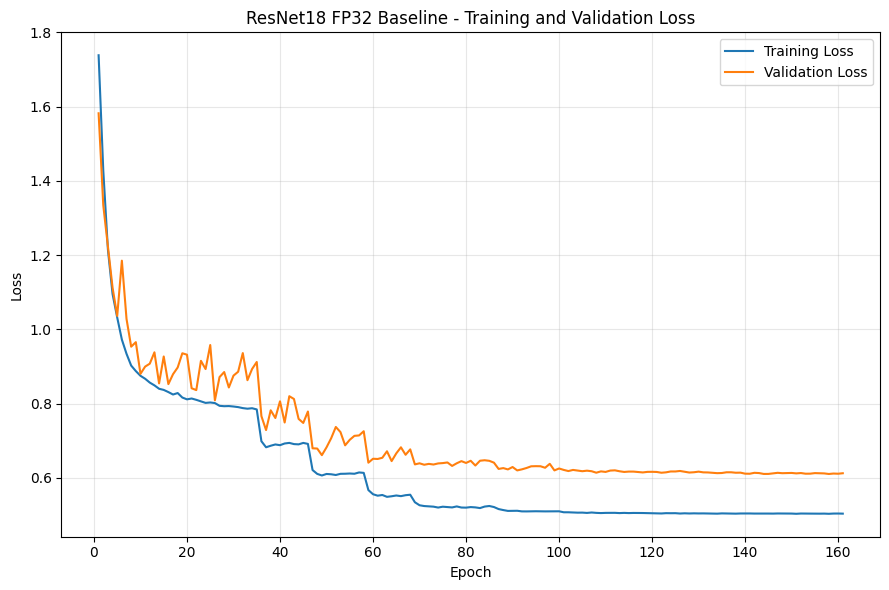

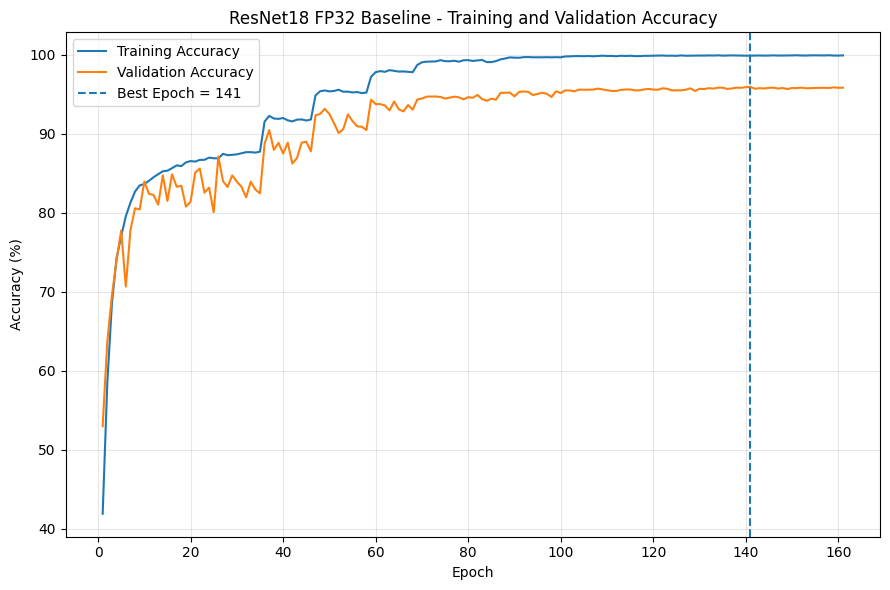

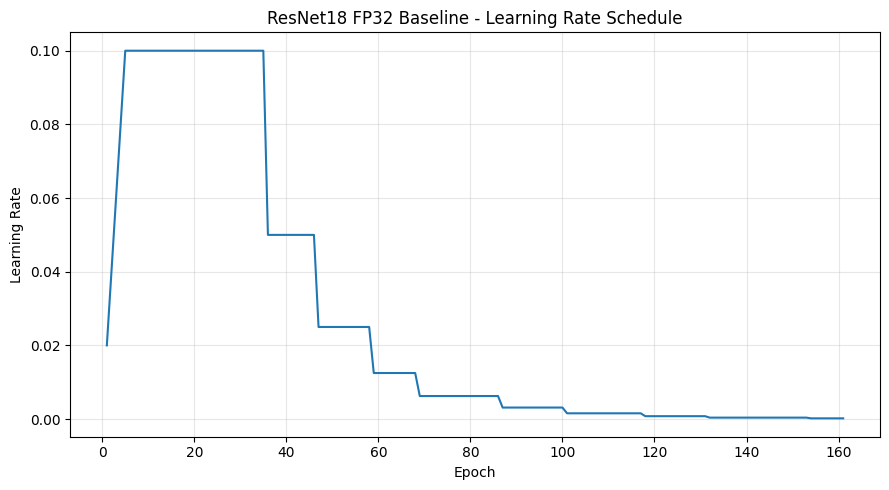

Plots saved to:
/kaggle/working/ATDL_Baseline_ResNet18/plots


In [18]:
# ============================================================
# CELL 13: Generate ResNet18 baseline training curves
# ============================================================

history_df = pd.read_csv(
    LOG_DIR / "training_history.csv"
)


# ------------------------------------------------------------
# Loss curves
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ResNet18 FP32 Baseline - Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "baseline_loss_curves.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Accuracy curves
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ResNet18 FP32 Baseline - Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "baseline_accuracy_curves.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Learning-rate curve
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["learning_rate"]
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.title(
    "ResNet18 FP32 Baseline - Learning Rate Schedule"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "baseline_learning_rate.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


print("Plots saved to:")
print(PLOT_DIR)

In [19]:
# ============================================================
# CELL 14: Reload best ResNet18 baseline checkpoint
# ============================================================

assert BEST_CHECKPOINT_PATH.exists(), (
    "baseline.pth was not found."
)


checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)


best_baseline = build_cifar_resnet18(
    num_classes=10
)


best_baseline.load_state_dict(
    checkpoint["model_state_dict"]
)


best_baseline = best_baseline.to(
    DEVICE
)

best_baseline.eval()


print("Best baseline checkpoint loaded.")

print(
    "Checkpoint epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation accuracy:",
    f"{checkpoint['best_val_accuracy']:.2f}%"
)

print(
    "Validation loss at best checkpoint:",
    f"{checkpoint['best_val_loss']:.4f}"
)


# ------------------------------------------------------------
# Verify checkpoint on validation set
# ------------------------------------------------------------

restored_val_loss, restored_val_accuracy = evaluate(
    best_baseline,
    val_loader,
    criterion,
    DEVICE
)


print("\nRestored checkpoint validation:")

print(
    f"Validation loss     : "
    f"{restored_val_loss:.4f}"
)

print(
    f"Validation accuracy : "
    f"{restored_val_accuracy:.2f}%"
)

Best baseline checkpoint loaded.
Checkpoint epoch: 141
Best validation accuracy: 95.94%
Validation loss at best checkpoint: 0.6108

Restored checkpoint validation:
Validation loss     : 0.6108
Validation accuracy : 95.94%


In [20]:
# ============================================================
# CELL 15: Clean train and official test datasets
# ============================================================

# ------------------------------------------------------------
# Clean full CIFAR-10 training set
# No random crop, flip, or Cutout.
# Used only to measure generalization gap.
# ------------------------------------------------------------

clean_train_dataset = datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=True,
    download=False,
    transform=eval_transform
)


clean_train_loader = DataLoader(
    clean_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0)
)


# ------------------------------------------------------------
# Official CIFAR-10 test set
# Used only after model selection.
# ------------------------------------------------------------

test_dataset = datasets.CIFAR10(
    root=str(CIFAR_ROOT),
    train=False,
    download=False,
    transform=eval_transform
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0)
)


print(
    "Clean training samples :",
    len(clean_train_dataset)
)

print(
    "Official test samples  :",
    len(test_dataset)
)


assert len(clean_train_dataset) == 50000
assert len(test_dataset) == 10000


print(
    "\nOfficial CIFAR-10 test set ready for final evaluation."
)

Clean training samples : 50000
Official test samples  : 10000

Official CIFAR-10 test set ready for final evaluation.


In [21]:
# ============================================================
# CELL 16: FINAL ResNet18 baseline evaluation
# ============================================================

print("=" * 72)
print("FINAL RESNET18 FP32 BASELINE EVALUATION")
print("=" * 72)


# ------------------------------------------------------------
# Clean training performance
# ------------------------------------------------------------

clean_train_loss, clean_train_accuracy = evaluate(
    best_baseline,
    clean_train_loader,
    criterion,
    DEVICE
)


# ------------------------------------------------------------
# Official CIFAR-10 test performance
# ------------------------------------------------------------

test_loss, test_accuracy = evaluate(
    best_baseline,
    test_loader,
    criterion,
    DEVICE
)


generalization_gap = (
    clean_train_accuracy -
    test_accuracy
)


print(
    f"Clean training loss     : "
    f"{clean_train_loss:.4f}"
)

print(
    f"Clean training accuracy : "
    f"{clean_train_accuracy:.2f}%"
)


print(
    f"\nBest validation loss    : "
    f"{restored_val_loss:.4f}"
)

print(
    f"Best validation accuracy: "
    f"{restored_val_accuracy:.2f}%"
)


print(
    f"\nOfficial test loss      : "
    f"{test_loss:.4f}"
)

print(
    f"Official test accuracy  : "
    f"{test_accuracy:.2f}%"
)


print(
    f"\nTrain-test accuracy gap : "
    f"{generalization_gap:.2f} percentage points"
)

FINAL RESNET18 FP32 BASELINE EVALUATION
Clean training loss     : 0.5117
Clean training accuracy : 99.59%

Best validation loss    : 0.6108
Best validation accuracy: 95.94%

Official test loss      : 0.6205
Official test accuracy  : 95.49%

Train-test accuracy gap : 4.10 percentage points


In [22]:
# ============================================================
# CELL 17: Save final ResNet18 baseline metrics
# ============================================================

checkpoint_size_bytes = os.path.getsize(
    BEST_CHECKPOINT_PATH
)


checkpoint_size_mib = (
    checkpoint_size_bytes /
    (1024 ** 2)
)


checkpoint_size_mb = (
    checkpoint_size_bytes /
    1_000_000
)


# Theoretical raw FP32 parameter storage
fp32_parameter_storage_bytes = (
    total_parameters * 32 / 8
)

fp32_parameter_storage_mib = (
    fp32_parameter_storage_bytes /
    (1024 ** 2)
)


final_metrics = {

    "model":
        "ResNet18 FP32 Baseline",

    "architecture":
        "ResNet18",

    "precision":
        "FP32",

    "knowledge_distillation":
        False,

    "quantization":
        False,

    "best_epoch":
        int(best_epoch),

    "epochs_completed":
        int(epochs_completed),

    "best_validation_loss":
        float(restored_val_loss),

    "best_validation_accuracy":
        float(restored_val_accuracy),

    "clean_training_loss":
        float(clean_train_loss),

    "clean_training_accuracy":
        float(clean_train_accuracy),

    "official_test_loss":
        float(test_loss),

    "official_test_accuracy":
        float(test_accuracy),

    "train_test_accuracy_gap":
        float(generalization_gap),

    "total_parameters":
        int(total_parameters),

    "trainable_parameters":
        int(trainable_parameters),

    "theoretical_fp32_parameter_storage_bytes":
        int(fp32_parameter_storage_bytes),

    "theoretical_fp32_parameter_storage_mib":
        float(fp32_parameter_storage_mib),

    "checkpoint_path":
        str(BEST_CHECKPOINT_PATH),

    "checkpoint_size_bytes":
        int(checkpoint_size_bytes),

    "checkpoint_size_mb":
        float(checkpoint_size_mb),

    "checkpoint_size_mib":
        float(checkpoint_size_mib),

    "random_seed":
        SEED,

    "test_set_used_for_model_selection":
        False
}


with open(
    RESULT_DIR /
    "baseline_final_metrics.json",
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )


print(
    json.dumps(
        final_metrics,
        indent=4
    )
)


print(
    "\nFinal metrics saved to:"
)

print(
    RESULT_DIR /
    "baseline_final_metrics.json"
)

{
    "model": "ResNet18 FP32 Baseline",
    "architecture": "ResNet18",
    "precision": "FP32",
    "knowledge_distillation": false,
    "quantization": false,
    "best_epoch": 141,
    "epochs_completed": 161,
    "best_validation_loss": 0.6108161935806274,
    "best_validation_accuracy": 95.94,
    "clean_training_loss": 0.5116744921112061,
    "clean_training_accuracy": 99.594,
    "official_test_loss": 0.6204554017066956,
    "official_test_accuracy": 95.49,
    "train_test_accuracy_gap": 4.103999999999999,
    "total_parameters": 11173962,
    "trainable_parameters": 11173962,
    "theoretical_fp32_parameter_storage_bytes": 44695848,
    "theoretical_fp32_parameter_storage_mib": 42.625282287597656,
    "checkpoint_path": "/kaggle/working/ATDL_Baseline_ResNet18/checkpoints/baseline.pth",
    "checkpoint_size_bytes": 44772555,
    "checkpoint_size_mb": 44.772555,
    "checkpoint_size_mib": 42.69843578338623,
    "random_seed": 42,
    "test_set_used_for_model_selection": false
}


In [23]:
# ============================================================
# CELL 19: Create Notebook 2 ZIP archive
# ============================================================

ZIP_BASE = (
    KAGGLE_WORKING_DIR /
    "ATDL_Baseline_ResNet18"
)


zip_path = shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir=str(KAGGLE_WORKING_DIR),
    base_dir=PROJECT_DIR.name
)


zip_size_mib = (
    os.path.getsize(zip_path) /
    (1024 ** 2)
)


print("=" * 72)
print("NOTEBOOK 2 EXPORT COMPLETE")
print("=" * 72)


print("\nZIP archive:")
print(zip_path)


print(
    f"\nZIP size: "
    f"{zip_size_mib:.2f} MiB"
)


print("\nBaseline checkpoint:")
print(BEST_CHECKPOINT_PATH)


print(
    f"\nBEST VALIDATION ACCURACY: "
    f"{restored_val_accuracy:.2f}%"
)


print(
    f"FINAL TEST ACCURACY: "
    f"{test_accuracy:.2f}%"
)


print(
    f"BEST EPOCH: "
    f"{best_epoch}"
)


print(
    f"CHECKPOINT SIZE: "
    f"{checkpoint_size_mib:.2f} MiB"
)


print(
    "\nAll Notebook 2 outputs are ready."
)

NOTEBOOK 2 EXPORT COMPLETE

ZIP archive:
/kaggle/working/ATDL_Baseline_ResNet18.zip

ZIP size: 40.11 MiB

Baseline checkpoint:
/kaggle/working/ATDL_Baseline_ResNet18/checkpoints/baseline.pth

BEST VALIDATION ACCURACY: 95.94%
FINAL TEST ACCURACY: 95.49%
BEST EPOCH: 141
CHECKPOINT SIZE: 42.70 MiB

All Notebook 2 outputs are ready.
